Breakdown time seems so long. Let's plot a long one.

In [1]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
%load_ext watermark
%watermark -v -p pandas,matplotlib,numpy

CPython 3.7.7
IPython 7.16.1

pandas 1.0.5
matplotlib 3.2.2
numpy 1.18.5


In [2]:
out_pth_ltf = Path('E:\\','Surfdrive','Screening_Data','out','Figure_LifetimeTraceFittedCaged.png')
out_pth_alt = Path('E:\\','Surfdrive','Screening_Data','out','Figure_AllLifetimeTracesCaged.png')
base_path = Path('E:\\','Surfdrive','Screening_Data_Mutable')
fit = Path(base_path,'2019','12','05','results','D07_fit.csv')
fit = pd.read_csv(fit)
tau = Path(base_path,'2019','12','05','results','D07_tau.csv')
tau = pd.read_csv(tau,'\t',header=None)
frameinterval = 2
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c)) 

In [3]:
fit_sel = fit[fit['breakdown time(s)'] > 20]
fit_sel = fit_sel[fit_sel['breakdown time(s)'] < 30]
fit_sel = fit_sel[fit_sel['error']==0]
fit_sel = fit_sel[fit_sel['e_breakdown time']<2]
fit_sel = fit_sel[fit_sel['start tau(ns)']<2.5]
fit_sel.head()

,Unnamed: 0,start(ns),range(ns),breakdown time(s),midpoint(s),start tau(ns),e_start,e_range,e_halftime,e_midpoint,error,condition,e_breakdown time
87,87,3.091137,-0.605129,29.684355,47.838246,2.490610,0.021229,0.022223,NaN,0.734063,0.0,Untransfected_cells,1.908346
100,100,3.122185,-0.614722,22.893409,49.380496,2.489605,0.019976,0.021210,NaN,0.628961,0.0,Untransfected_cells,1.926929
143,143,3.088732,-0.594603,24.617849,51.618535,2.478079,0.017366,0.018652,NaN,0.618742,0.0,Untransfected_cells,1.934369
149,149,3.051606,-0.581348,28.621665,56.342743,2.498417,0.014173,0.015656,NaN,0.613071,0.0,Untransfected_cells,1.982493
154,154,3.072309,-0.606776,24.723884,51.382756,2.468448,0.014770,0.015838,NaN,0.513034,0.0,Untransfected_cells,1.594593


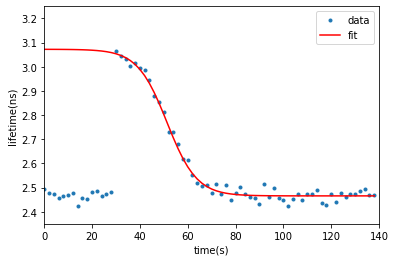

In [4]:
curve_nr = 154;
fig = plt.figure(1)
fit_vals= fit.loc[curve_nr,:]
xax = np.arange(0,frameinterval*len(tau.columns),frameinterval)
y_fit = fit_function(xax,fit_vals['start(ns)'],fit_vals['range(ns)'],fit_vals['breakdown time(s)'],fit_vals['midpoint(s)'])
y_tau = tau.loc[curve_nr,:]
plt.plot(xax,y_tau,'.',xax,y_fit,'r-')
plt.xlabel('time(s)')
plt.ylabel('lifetime(ns)')
plt.legend(['data','fit'])
plt.ylim([2.35,3.25])
plt.xlim([0,140])
fig.savefig(out_pth_ltf,dpi=600)

In [5]:
fit_vals

Unnamed: 0                           154
start(ns)                        3.07231
range(ns)                      -0.606776
breakdown time(s)                24.7239
midpoint(s)                      51.3828
start tau(ns)                    2.46845
e_start                        0.0147701
e_range                        0.0158377
e_halftime                           NaN
e_midpoint                      0.513034
error                                  0
condition            Untransfected_cells
e_breakdown time                 1.59459
Name: 154, dtype: object

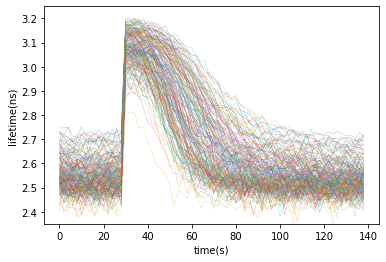

In [6]:
fig = plt.figure(2)
tau_error_free = tau[fit['error']==0]
for i in range(len(tau_error_free)):
    plt.plot(xax,tau_error_free.iloc[i,:],LineWidth=0.2)
plt.xlabel('time(s)')
plt.ylabel('lifetime(ns)')
plt.ylim([2.35,3.25])
fig.savefig(out_pth_alt,dpi=600)

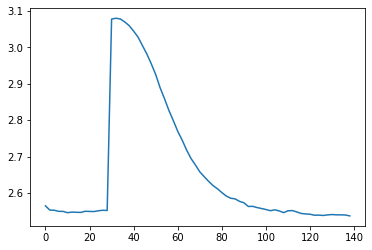

In [7]:
tefm = tau_error_free.to_numpy()
tefm = np.mean(tefm,axis=0)
plt.plot(xax,tefm)